## Digit Recognition (ANN)

## Information about Dataset

* MNIST stands for Modified National Institute of Standards and Technology database. In the world of Machine Learning, it is considered the "Hello World" dataset—the standard starting point for anyone learning how to build neural networks.Basically, it is a massive collection of handwritten digits used to train computers to recognize numbers.

* MNIST at a GlanceThe Content: It contains 70,000 small, grayscale images of digits from 0 to 9.

* The Split: Usually, 60,000 images are used for training the model, and 10,000 are kept aside for testing (to see how well the model learned)

* The Format: Each image is exactly 28 x 28 pixels.The Color: It's grayscale, meaning each pixel has a value from 0 (black) to 255 (white).

## Step 1: Import Libraries + Load Dataset

In [ ]:
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
# Flatten Layer: It converts a 2D image of 28 x 28 pixels into a 1D array of 784 individual elements. 
from tensorflow.keras.layers import Dense, Flatten

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Shape of data
print("Training data: ", X_train.shape)
print("Testing data", X_test.shape)

# Data Normalization:
# Raw pixel values range from 0 to 255. By dividing by 255, we scale them to a range between 0 and 1.
X_train= X_train/ 255
X_test= X_test/ 255

# OneHotEncoder
y_train= to_categorical(y_train)
y_test= to_categorical(y_test)


Training data:  (60000, 28, 28)
Testing data (10000, 28, 28)


## Step 2: Building ANN model

In [ ]:
model= Sequential()
model.add(Flatten(input_shape= (28,28)))
model.add(Dense(128, activation= "relu"))
model.add(Dense(64, activation= "relu"))
model.add(Dense(10, activation= "softmax"))

model.compile(optimizer= "adam", loss= "categorical_crossentropy", metrics= ["accuracy"])

# validation_split=0.1: This reserves 10% of your training data to act as a "mini-test" during the training process. 
history= model.fit(X_train, y_train, epochs= 8, batch_size= 20, validation_split=0.1)

loss, acc= model.evaluate(X_test, y_test)
print("Accuracy: ",acc)
print("Loss: ",loss)

c:\miniconda3\envs\ai_master\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/8
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9300 - loss: 0.2371 - val_accuracy: 0.9670 - val_loss: 0.1102
Epoch 2/8
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9674 - loss: 0.1041 - val_accuracy: 0.9720 - val_loss: 0.0894
Epoch 3/8
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9783 - loss: 0.0703 - val_accuracy: 0.9767 - val_loss: 0.0832
Epoch 4/8
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9823 - loss: 0.0558 - val_accuracy: 0.9747 - val_loss: 0.0932
Epoch 5/8
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9856 - loss: 0.0436 - val_accuracy: 0.9757 - val_loss: 0.0915
Epoch 6/8
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9884 - loss: 0.0358 - val_accuracy: 0.9758 - val_loss: 0.0934
Epoch 7/8
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9895 - loss: 0.0313 - val_accuracy: 0.9768 - val_loss: 0.0994
Epoch 8/8
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9912 - loss: 0.0264 - 

## Step 3: Ploting

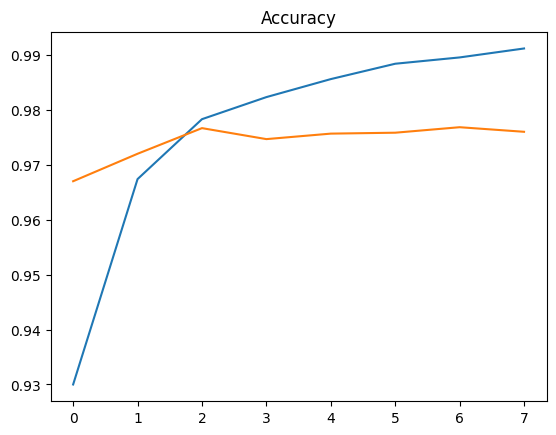

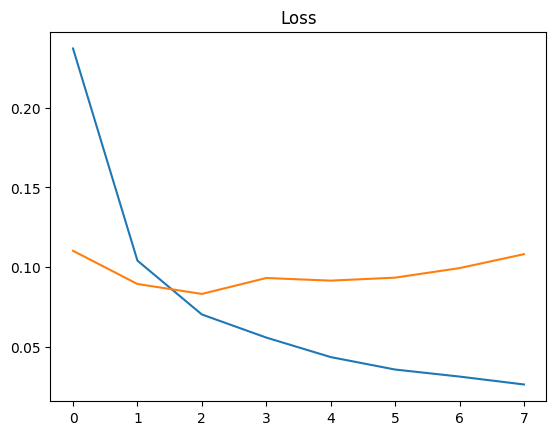

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"])
# history.history["val_accuracy"]: The ["val_accuracy"] key inside its dictionary contains a list of the 
# accuracy scores achieved on the validation data at the end of each epoch.
plt.plot(history.history["val_accuracy"]) 
plt.title("Accuracy")
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.show()

## Step 4: Prediction

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


array([5, 0, 4, ..., 5, 6, 8], shape=(60000,))

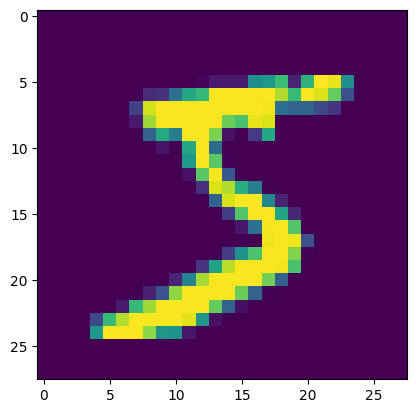

In [4]:
# Show the image 
plt.imshow (X_train[0])

prob= model.predict(X_train)
prob.argmax(axis=1)